# Avance 4 – Modelos alternativos y ajuste fino (Equipo 20)
**Equipo:** Equipo 20  
**Integrantes:**  
- Francisco Javier Rodríguez Echevarría - A01795970
- Gabriel Sareñana Labra - A01795507
- Yamil Abraham Nechar Reyes - A01795726

**Fecha:** 22/02/26

**Proyecto:** Detección / clasificación de anillos galácticos (Legacy Survey)  
**Metodología:** CRISP-ML(Q) – Modelado  
**Continuidad con Avance 3:** se mantiene el uso de `dataset.csv`, el enfoque de clases y las métricas (F1-macro como principal, además de Accuracy y Cohen’s Kappa), con split estratificado y `RANDOM_STATE=42`.  

**Feedback integrado:**
- Unsharp Masking (implementación: dividir imagen entre blur)
- Evaluar RGB Lupton vs alternativas basadas en color (por ejemplo, índices)
- Evaluar modelo pre-entrenado especializado en galaxias (Zoobot)
- Integrar nuevo catálogo y descargar imágenes (consumimos el CSV final con paths del Downloader)

> Nota: algunas secciones de CNN pueden requerir GPU para tiempos razonables.


## 0. Configuración general


In [72]:
!pip install imblearn

In [73]:
from pathlib import Path
import os, time, json, random
import numpy as np
import pandas as pd
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

smote = SMOTE(random_state=RANDOM_STATE)

current_dir = os.getcwd()
path = os.path.join(current_dir)
data_path = os.path.join(path, 'Data')
os.makedirs(data_path, exist_ok=True)
model_path = os.path.join(path, 'Models')
os.makedirs(model_path, exist_ok=True)
image_path = os.path.join(path, 'Images')
os.makedirs(image_path, exist_ok=True)
report_path = os.path.join(path, 'Reports')
os.makedirs(report_path, exist_ok=True)

HOME_PATH = path
DATA_PATH = data_path
IMAGE_PATH = image_path
MODEL_PATH = model_path
REPORT_PATH = report_path

print(f"HOME_PATH: {HOME_PATH}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"IMAGE_PATH: {IMAGE_PATH}")
print(f"MODEL_PATH: {MODEL_PATH}")
print(f"REPORT_PATH: {REPORT_PATH}")

DATA_DIR   = Path(DATA_PATH).resolve()
IMAGES_DIR = Path(IMAGE_PATH).resolve()
MODELS_DIR = Path(MODEL_PATH).resolve()
REPORTS_DIR = Path(REPORT_PATH).resolve()

for p in [DATA_DIR, IMAGES_DIR, MODELS_DIR, REPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

MAIN_CSV = DATA_DIR / "dataset_with_images.csv"

RING_CLASSES = [4, 8, 12]
CLASS_TO_INDEX = {c:i for i,c in enumerate(RING_CLASSES)}
INDEX_TO_CLASS = {i:c for c,i in CLASS_TO_INDEX.items()}

PRIMARY_METRIC = "f1_macro"




HOME_PATH: c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Avance 4
DATA_PATH: c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Avance 4\Data
IMAGE_PATH: c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Avance 4\Images
MODEL_PATH: c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Avance 4\Models
REPORT_PATH: c:\Users\Francisco-PC\Documents\Tec de Monterrey\Proyecto Integrador\Experimentos\Avance 4\Reports


## 1. Utilidades: métricas, splits y tabla comparativa


In [74]:
from dataclasses import dataclass
from typing import Dict, Any, List

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, classification_report, confusion_matrix

@dataclass
class EvalResult:
    model_name: str
    params: Dict[str, Any]
    train_time_sec: float
    fit_time_sec: float
    predict_time_sec: float
    accuracy: float
    f1_macro: float
    kappa: float

def stratified_split(X, y, test_size=0.2, val_size=0.1, random_state=RANDOM_STATE):
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    val_ratio = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=val_ratio, stratify=y_trainval, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name: str, params: Dict[str, Any]=None) -> EvalResult:
    if params is None:
        params = {}
    t0 = time.time()

    tf0 = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - tf0

    tp0 = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - tp0

    total_time = time.time() - t0

    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    kap = cohen_kappa_score(y_test, y_pred)

    return EvalResult(model_name, params, total_time, fit_time, pred_time, acc, f1m, kap)

def results_to_df(results: List[EvalResult]) -> pd.DataFrame:
    rows = []
    for r in results:
        rows.append({
            "model": r.model_name,
            "f1_macro": r.f1_macro,
            "accuracy": r.accuracy,
            "kappa": r.kappa,
            "train_time_sec": r.train_time_sec,
            "fit_time_sec": r.fit_time_sec,
            "predict_time_sec": r.predict_time_sec,
            "params": json.dumps(r.params, ensure_ascii=False)
        })
    df = pd.DataFrame(rows).sort_values(by=PRIMARY_METRIC, ascending=False).reset_index(drop=True)
    return df


## 2. Carga y preparación del dataset tabular


In [75]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import csv

if not MAIN_CSV.exists():
    raise FileNotFoundError(f"No se encontró {MAIN_CSV}")

def read_flexible_csv(path):
    """Lee CSVs generados por distintos flujos (incluyendo casos donde todo viene entre comillas)."""
    attempts = [
        dict(),                       # default (coma)
        dict(sep=";"),
        dict(sep="\t"),
        dict(sep=",", quoting=csv.QUOTE_NONE, engine="python"),
        dict(sep=";", quoting=csv.QUOTE_NONE, engine="python"),
        dict(sep="\t", quoting=csv.QUOTE_NONE, engine="python"),
    ]
    last_err = None
    for kwargs in attempts:
        try:
            df_try = pd.read_csv(path, **kwargs)
        except Exception as e:
            last_err = e
            continue

        # Caso común: todo el renglón viene entre comillas y Pandas lo interpreta como 1 sola columna
        if df_try.shape[1] == 1:
            col = df_try.columns[0]
            if isinstance(col, str) and "," in col:
                cols = [x.strip().strip('"') for x in col.split(",")]
                raw = df_try.iloc[:, 0].astype(str).str.strip().str.strip('"')
                expanded = raw.str.split(",", expand=True)
                if expanded.shape[1] == len(cols):
                    expanded.columns = cols
                    return expanded

        if ("anillos" in df_try.columns) or ("ring_class" in df_try.columns):
            return df_try

    raise ValueError(f"No pude parsear el CSV {path}. Último error: {last_err}")

df = read_flexible_csv(MAIN_CSV)
print("Shape original:", df.shape)

# --- Asegurar tipos numéricos para evitar filtros vacíos ---
for col in ["ra", "dec", "z", "anillos", "ring_class"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# eliminar filas sin datos críticos
df = df.dropna(subset=["ra", "dec", "z", "anillos", "ring_class"]).copy()

# normalizar formato (ej. 4.0 -> 4)
df["anillos"] = df["anillos"].round().astype(int)
df["ring_class"] = df["ring_class"].round().astype(int)

# Continuidad Avance 3: trabajar solo con galaxias con anillos (4, 8, 12)
df = df[df["anillos"].isin(RING_CLASSES)].copy()
print("Shape filtrado (solo anillos):", df.shape)
print("Distribución anillos:", df["anillos"].value_counts().to_dict())

# Target: usar ring_class del downloader (índices consecutivos)
y = df["ring_class"].astype(int).copy()

# Features tabulares (continuidad Avance 3 + FE ligera)
df["z_log1p"] = np.log1p(df["z"].clip(lower=0))
df["ra_rad"] = np.deg2rad(df["ra"])
df["dec_rad"] = np.deg2rad(df["dec"])
df["ra_sin"] = np.sin(df["ra_rad"])
df["ra_cos"] = np.cos(df["ra_rad"])
df["dec_sin"] = np.sin(df["dec_rad"])
df["dec_cos"] = np.cos(df["dec_rad"])

# Binning de z como feature categórica
df["z_bin"] = pd.qcut(df["z"], q=3, labels=["low", "mid", "high"])

# Selección de columnas de entrada (evitar leakage)
drop_cols = {
    "id_str", "file_loc",
    "anillos", "ring_class",
    "ring_class_0", "ring_class_1", "ring_class_2", "ring_class_3",
    "ra_rad", "dec_rad"
}
feature_cols = [c for c in df.columns if c not in drop_cols]

numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

X = df[feature_cols].copy()

# Split estratificado (reproducible)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

print("Split sizes:", X_train.shape, X_val.shape, X_test.shape)

preprocess_tabular = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop"
)


Shape original: (7698, 11)
Shape filtrado (solo anillos): (1371, 11)
Distribución anillos: {4: 833, 12: 361, 8: 177}
Split sizes: (1096, 9) (137, 9) (138, 9)


## 3. Seis modelos tabulares (individuales, no ensambles) + comparativa


In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

models = []
models.append(("LogisticRegression",
               Pipeline([("preprocess", preprocess),
                        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))]),
               {"clf__C": 1.0}))

models.append(("LinearSVC",
               Pipeline([("preprocess", preprocess),
                        ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE))]),
               {"clf__C": 1.0}))

models.append(("KNN",
               Pipeline([("preprocess", preprocess),
                        ("clf", KNeighborsClassifier(n_neighbors=15))]),
               {"clf__n_neighbors": 15}))

models.append(("GaussianNB",
               Pipeline([("preprocess", preprocess),
                        ("clf", GaussianNB())]),
               {}))

models.append(("DecisionTree",
               Pipeline([("preprocess", preprocess),
                        ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE))]),
               {"clf__max_depth": None}))

models.append(("MLPClassifier",
               Pipeline([("preprocess", preprocess),
                        ("clf", MLPClassifier(hidden_layer_sizes=(128,64), max_iter=300, random_state=RANDOM_STATE))]),
               {"clf__hidden_layer_sizes": (128,64)}))

baseline_results = []
for name, pipe, params in models:
    r = evaluate_classifier(pipe, X_train, y_train, X_test, y_test, model_name=name, params=params)
    baseline_results.append(r)
    print(name, "F1:", round(r.f1_macro,4), "Acc:", round(r.accuracy,4), "Kappa:", round(r.kappa,4), "Time(s):", round(r.train_time_sec,2))

baseline_table = results_to_df(baseline_results)
baseline_table


LogisticRegression F1: 0.3362 Acc: 0.3623 Kappa: 0.0439 Time(s): 0.03
LinearSVC F1: 0.2794 Acc: 0.5942 Kappa: 0.0039 Time(s): 0.02
KNN F1: 0.2477 Acc: 0.587 Kappa: -0.029 Time(s): 0.02
GaussianNB F1: 0.2968 Acc: 0.5507 Kappa: 0.0166 Time(s): 0.01
DecisionTree F1: 0.3661 Acc: 0.4783 Kappa: 0.0287 Time(s): 0.02
MLPClassifier F1: 0.3269 Acc: 0.5435 Kappa: -0.0147 Time(s): 1.69


,model,f1_macro,accuracy,kappa,train_time_sec,fit_time_sec,predict_time_sec,params
0,DecisionTree,0.366136,0.478261,0.028739,0.017498,0.014334,0.003162,"{""clf__max_depth"": null}"
1,LogisticRegression,0.336241,0.362319,0.043930,0.034302,0.028318,0.005982,"{""clf__C"": 1.0}"
2,MLPClassifier,0.326944,0.543478,-0.014706,1.688875,1.683750,0.005124,"{""clf__hidden_layer_sizes"": [128, 64]}"
3,GaussianNB,0.296806,0.550725,0.016552,0.009106,0.005337,0.003768,{}
4,LinearSVC,0.279434,0.594203,0.003867,0.019411,0.014923,0.004486,"{""clf__C"": 1.0}"
5,KNN,0.247706,0.586957,-0.029042,0.018347,0.013345,0.005001,"{""clf__n_neighbors"": 15}"


Implementamos SMOTE para rebalancear las clases ya que actualmente los modelos favorecieron a la clase mayoritaria por eso es que tenemos una presicion tan baja

In [77]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

smote = SMOTE(random_state=RANDOM_STATE)

models_rebalanced = {
    "DecisionTree_SMOTE": ImbPipeline([
        ("preprocess", preprocess_tabular),
        ("smote", smote),
        ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),
    "LogisticRegression_SMOTE": ImbPipeline([
        ("preprocess", preprocess_tabular),
        ("smote", smote),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),
    "LinearSVC_SMOTE": ImbPipeline([
        ("preprocess", preprocess_tabular),
        ("smote", smote),
        ("clf", LinearSVC(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),
    "KNN_SMOTE": ImbPipeline([
        ("preprocess", preprocess_tabular),
        ("smote", smote),
        ("clf", KNeighborsClassifier(n_neighbors=15))
    ]),
    "GaussianNB_SMOTE": ImbPipeline([
        ("preprocess", preprocess_tabular),
        ("smote", smote),
        ("clf", GaussianNB())
    ]),
    "MLP_SMOTE": ImbPipeline([
        ("preprocess", preprocess_tabular),
        ("smote", smote),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            max_iter=800,
            early_stopping=True,
            random_state=RANDOM_STATE
        ))
    ]),
}

In [78]:
import time
from sklearn.metrics import f1_score, accuracy_score, cohen_kappa_score

def evaluate_model(model, X_train, y_train, X_test, y_test):
    t0 = time.time()
    fit0 = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - fit0

    pred0 = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - pred0

    total_time = time.time() - t0

    return {
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "accuracy": accuracy_score(y_test, y_pred),
        "kappa": cohen_kappa_score(y_test, y_pred),
        "train_time_sec": total_time,
        "fit_time_sec": fit_time,
        "predict_time_sec": pred_time
    }

rows = []
for name, model in models_rebalanced.items():
    metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
    rows.append({"model": name, **metrics})

df_compare_smote = pd.DataFrame(rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)
df_compare_smote

,model,f1_macro,accuracy,kappa,train_time_sec,fit_time_sec,predict_time_sec
0,DecisionTree_SMOTE,0.355554,0.456522,0.051155,0.023861,0.020751,0.003109
1,GaussianNB_SMOTE,0.334909,0.355072,0.050997,0.010649,0.007805,0.002843
2,LogisticRegression_SMOTE,0.307815,0.333333,0.006573,0.026624,0.023726,0.002898
3,LinearSVC_SMOTE,0.307638,0.333333,0.007970,0.014911,0.012034,0.002876
4,KNN_SMOTE,0.283147,0.311594,-0.068982,0.013777,0.009754,0.004023
5,MLP_SMOTE,0.274388,0.318841,-0.077767,0.790876,0.787461,0.003415


Se aplicó SMOTE para mitigar el desbalance de clases en el conjunto de entrenamiento; sin embargo, no se observó una mejora significativa en la métrica principal (F1 macro). Esto sugiere que el problema no se debe únicamente al desbalance, sino a la limitada capacidad de las variables tabulares (ra, dec, z y transformaciones derivadas) para capturar la morfología galáctica.

En consecuencia, la mejora del rendimiento requiere incorporar información visual mediante modelos basados en imágenes, capaces de aprender patrones espaciales asociados a los anillos.

### 3.1 Tabla comparativa (ordenada por F1-macro)


In [79]:
baseline_table.to_csv(REPORTS_DIR / "tabular_models_comparison.csv", index=False)
baseline_table


,model,f1_macro,accuracy,kappa,train_time_sec,fit_time_sec,predict_time_sec,params
0,DecisionTree,0.366136,0.478261,0.028739,0.017498,0.014334,0.003162,"{""clf__max_depth"": null}"
1,LogisticRegression,0.336241,0.362319,0.043930,0.034302,0.028318,0.005982,"{""clf__C"": 1.0}"
2,MLPClassifier,0.326944,0.543478,-0.014706,1.688875,1.683750,0.005124,"{""clf__hidden_layer_sizes"": [128, 64]}"
3,GaussianNB,0.296806,0.550725,0.016552,0.009106,0.005337,0.003768,{}
4,LinearSVC,0.279434,0.594203,0.003867,0.019411,0.014923,0.004486,"{""clf__C"": 1.0}"
5,KNN,0.247706,0.586957,-0.029042,0.018347,0.013345,0.005001,"{""clf__n_neighbors"": 15}"


## 4. Selección de top-2 tabulares y ajuste fino (GridSearchCV)


In [80]:
from sklearn.model_selection import GridSearchCV

top2 = baseline_table["model"].head(2).tolist()
top2


['DecisionTree', 'LogisticRegression']

In [81]:
param_grids = {
    "LogisticRegression": {
        "clf__C": [0.1, 1.0, 3.0, 10.0],
        "clf__solver": ["lbfgs"],
        "clf__penalty": ["l2"],
    },
    "LinearSVC": {
        "clf__C": [0.1, 1.0, 3.0, 10.0],
        "clf__loss": ["hinge", "squared_hinge"],
    },
    "KNN": {
        "clf__n_neighbors": [5, 9, 15, 25, 35],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2],
    },
    "GaussianNB": {
        "clf__var_smoothing": [1e-12, 1e-10, 1e-9, 1e-8]
    },
    "DecisionTree": {
        "clf__max_depth": [None, 5, 10, 20],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4],
        "clf__ccp_alpha": [0.0, 0.001, 0.01]
    },
    "MLPClassifier": {
        "clf__hidden_layer_sizes": [(64,), (128,), (128,64), (256,128)],
        "clf__alpha": [1e-5, 1e-4, 1e-3],
        "clf__learning_rate_init": [1e-3, 5e-4, 1e-4],
    }
}
name_to_pipe = {name: pipe for name, pipe, _ in models}

tuned_results = []
best_estimators = {}

for model_name in top2:
    pipe = name_to_pipe[model_name]
    grid = param_grids.get(model_name, {})
    print(f"\n=== GridSearchCV: {model_name} ===")
    gs = GridSearchCV(pipe, grid, scoring="f1_macro", cv=5, n_jobs=-1, verbose=1)
    t0 = time.time()
    gs.fit(X_train, y_train)
    train_time = time.time() - t0

    best_estimators[model_name] = gs.best_estimator_
    print("Best params:", gs.best_params_)
    print("Best CV f1_macro:", gs.best_score_)

    y_pred = gs.best_estimator_.predict(X_test)
    tuned_results.append(EvalResult(
        model_name=f"{model_name} (tuned)",
        params=gs.best_params_,
        train_time_sec=train_time,
        fit_time_sec=train_time,
        predict_time_sec=float("nan"),
        accuracy=accuracy_score(y_test, y_pred),
        f1_macro=f1_score(y_test, y_pred, average="macro"),
        kappa=cohen_kappa_score(y_test, y_pred),
    ))

tuned_table = results_to_df(tuned_results)
tuned_table



=== GridSearchCV: DecisionTree ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'clf__ccp_alpha': 0.0, 'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5}
Best CV f1_macro: 0.3416422502654374

=== GridSearchCV: LogisticRegression ===
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'clf__C': 10.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best CV f1_macro: 0.3500988271551659


,model,f1_macro,accuracy,kappa,train_time_sec,fit_time_sec,predict_time_sec,params
0,DecisionTree (tuned),0.385143,0.456522,0.100626,17.696444,17.696444,NaN,"{""clf__ccp_alpha"": 0.0, ""clf__max_depth"": null..."
1,LogisticRegression (tuned),0.326340,0.355072,0.028015,0.103888,0.103888,NaN,"{""clf__C"": 10.0, ""clf__penalty"": ""l2"", ""clf__s..."


## 5. Selección tabular final (baseline vs tuned)


In [82]:
combined = pd.concat([
    baseline_table.assign(stage="baseline"),
    tuned_table.assign(stage="tuned")
], ignore_index=True).sort_values(by="f1_macro", ascending=False).reset_index(drop=True)

combined.to_csv(REPORTS_DIR / "tabular_baseline_vs_tuned.csv", index=False)
combined


,model,f1_macro,accuracy,kappa,train_time_sec,fit_time_sec,predict_time_sec,params,stage
0,DecisionTree (tuned),0.385143,0.456522,0.100626,17.696444,17.696444,NaN,"{""clf__ccp_alpha"": 0.0, ""clf__max_depth"": null...",tuned
1,DecisionTree,0.366136,0.478261,0.028739,0.017498,0.014334,0.003162,"{""clf__max_depth"": null}",baseline
2,LogisticRegression,0.336241,0.362319,0.043930,0.034302,0.028318,0.005982,"{""clf__C"": 1.0}",baseline
3,MLPClassifier,0.326944,0.543478,-0.014706,1.688875,1.683750,0.005124,"{""clf__hidden_layer_sizes"": [128, 64]}",baseline
4,LogisticRegression (tuned),0.326340,0.355072,0.028015,0.103888,0.103888,NaN,"{""clf__C"": 10.0, ""clf__penalty"": ""l2"", ""clf__s...",tuned
5,GaussianNB,0.296806,0.550725,0.016552,0.009106,0.005337,0.003768,{},baseline
6,LinearSVC,0.279434,0.594203,0.003867,0.019411,0.014923,0.004486,"{""clf__C"": 1.0}",baseline
7,KNN,0.247706,0.586957,-0.029042,0.018347,0.013345,0.005001,"{""clf__n_neighbors"": 15}",baseline


## 6. Modelos de imagen (estructura uniforme) 


In [83]:
import warnings
warnings.filterwarnings("ignore")

from astropy.io import fits

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cuda


### 6.1 Preprocesamiento: Lupton RGB y Unsharp divide (feedback)


In [84]:
import numpy as np
from scipy.ndimage import gaussian_filter

def safe_minmax(x: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    mn, mx = float(x.min()), float(x.max())
    if (mx - mn) < eps:
        return np.zeros_like(x, dtype=np.float32)
    return ((x - mn) / (mx - mn)).astype(np.float32)

def asinh_scale(x: np.ndarray, a: float = 10.0) -> np.ndarray:
    return np.arcsinh(a * x) / np.arcsinh(a)

def lupton_rgb(g: np.ndarray, r: np.ndarray, z: np.ndarray) -> np.ndarray:
    g = safe_minmax(g); r = safe_minmax(r); z = safe_minmax(z)
    rgb = np.stack([z, r, g], axis=-1)
    rgb = asinh_scale(rgb, a=10.0)
    return np.clip(rgb, 0.0, 1.0).astype(np.float32)

def gaussian_blur(img: np.ndarray, sigma: float = 1.5) -> np.ndarray:
    import scipy.ndimage as ndi
    return ndi.gaussian_filter(img, sigma=sigma)

def unsharp_divide(img: np.ndarray, sigma: float = 1.5, eps: float = 1e-6) -> np.ndarray:
    blurred = gaussian_blur(img, sigma=sigma)
    out = img / (blurred + eps)
    return safe_minmax(out)

def unsharp_mask(image: np.ndarray, sigma: float = 1.0, amount: float = 1.0, threshold: float = 0):
    """
    Applies unsharp masking to a numpy array.
    
    Parameters:
    - image: input numpy array (2D for grayscale, 3D for RGB).
    - sigma: standard deviation for Gaussian blur (controls the width of the edges).
    - amount: multiplier for the sharpening effect (usually 0.5 to 2.0).
    - threshold: minimum brightness change to be sharpened (helps reduce noise).
    """
    # 1. Create the blurred version of the image
    # For RGB images, we don't blur along the color channel axis
    if image.ndim == 3:
        blurred = gaussian_filter(image, sigma=(sigma, sigma, 0))
    else:
        blurred = gaussian_filter(image, sigma=sigma)
    
    # 2. Calculate the mask (Original / Blurred)
    mask = image / blurred
    
    # 3. Apply thresholding if needed to avoid sharpening noise
    if threshold > 0:
        mask[np.abs(mask) < threshold] = 0
    
    # 4. Add the weighted mask back to the original image
    sharpened = image + amount * mask
    
    return blurred, sharpened


### 6.2 Dataset FITS para CNN


In [85]:
class FitsRGBDataset(Dataset):
    def __init__(self, df: pd.DataFrame, mode: str = "lupton_rgb", resize: int = 224):
        self.df = df.reset_index(drop=True)
        self.mode = mode
        self.to_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((resize, resize), antialias=True),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["file_loc"]
        y = int(row["ring_class_idx"])

        with fits.open(path, memmap=False) as hdul:
            arr = np.array(hdul[0].data, dtype=np.float32)

        if arr.ndim == 2:
            img = safe_minmax(arr)
            img = np.stack([img, img, img], axis=-1)
        elif arr.ndim == 3:
            if arr.shape[0] == 3 and arr.shape[-1] != 3:
                g, r, z = arr[0], arr[1], arr[2]
                img = lupton_rgb(g, r, z)
            elif arr.shape[-1] == 3:
                img = safe_minmax(arr)
            else:
                img = safe_minmax(arr)
                if img.shape[0] == 3:
                    img = np.transpose(img, (1,2,0))
                img = img[..., :3]
        else:
            raise ValueError(f"FITS con dimensiones inesperadas: {arr.shape}")

        if self.mode == "unsharp_lupton":
            img = unsharp_divide(img, sigma=1.5)
        if self.mode == "unsharp_mask":
            _, img = unsharp_mask(img, sigma=5.5, amount=3.5, threshold=0.01)

        x = self.to_tensor(img)
        return x, torch.tensor(y, dtype=torch.long)


### 6.3 Carga del CSV de imágenes y splits


In [86]:
from pathlib import Path

df_img = df.copy()

print("Dataset imágenes listo:", df_img.shape)
print(df_img.describe())

# Ahora redefinimos X e y SOLO con imágenes válidas
y_img = df_img["ring_class"].astype(int)
X_img = df_img.drop(columns=["ring_class"])

# Nuevo split estratificado
from sklearn.model_selection import train_test_split

X_train_img, X_temp_img, y_train_img, y_temp_img = train_test_split(
    X_img, y_img, test_size=0.2, stratify=y_img, random_state=RANDOM_STATE
)

X_val_img, X_test_img, y_val_img, y_test_img = train_test_split(
    X_temp_img, y_temp_img, test_size=0.5, stratify=y_temp_img, random_state=RANDOM_STATE
)

print("Splits imágenes:",
      X_train_img.shape,
      X_val_img.shape,
      X_test_img.shape)

Dataset imágenes listo: (1371, 19)
             id_str           ra          dec            z      anillos  \
count  1.371000e+03  1371.000000  1371.000000  1371.000000  1371.000000   
mean   1.237662e+18   179.746088    25.231994     0.035758     6.622903   
std    6.066126e+12    59.943354    18.661302     0.012378     3.470842   
min    1.237649e+18     2.142880   -10.949290     0.010153     4.000000   
25%    1.237658e+18   148.947510     9.934048     0.026374     4.000000   
50%    1.237662e+18   176.107310    24.025733     0.033725     4.000000   
75%    1.237666e+18   216.834840    39.165154     0.044452    12.000000   
max    1.237680e+18   359.032580    68.594576     0.065933    12.000000   

        ring_class  ring_class_0  ring_class_1  ring_class_2  ring_class_3  \
count  1371.000000        1371.0   1371.000000   1371.000000   1371.000000   
mean      1.655726           0.0      0.607586      0.129103      0.263311   
std       0.867711           0.0      0.488466      0.3

## 7. CNNs alternas (no ensambles): ResNet18, MobileNetV3, EfficientNet-B0


In [87]:
import time
import numpy as np

import torch
import torch.nn as nn
import torchvision
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

def build_torch_model(model_name: str, num_classes: int):
    model_name = model_name.lower()

    if model_name == "resnet18":
        m = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        return m

    if model_name == "mobilenet_v3_small":
        m = torchvision.models.mobilenet_v3_small(weights=torchvision.models.MobileNet_V3_Small_Weights.DEFAULT)
        m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, num_classes)
        return m

    if model_name == "efficientnet_b0":
        m = torchvision.models.efficientnet_b0(weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT)
        m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, num_classes)
        return m

    raise ValueError(f"Modelo no soportado: {model_name}")

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / max(total, 1), correct / max(total, 1)

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ys, preds_all = [], []

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        out = model(x)
        loss = criterion(out, y)

        total_loss += loss.item() * y.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        ys.append(y.cpu().numpy())
        preds_all.append(preds.cpu().numpy())

    y_true = np.concatenate(ys) if ys else np.array([])
    y_pred = np.concatenate(preds_all) if preds_all else np.array([])

    return total_loss / max(total, 1), correct / max(total, 1), y_true, y_pred

def compute_metrics_np(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "kappa": cohen_kappa_score(y_true, y_pred),
    }

Using device: cuda


In [89]:
CNN_EPOCHS = 5
CNN_BATCH_SIZE = 32
CNN_LR = 1e-4

cnn_runs = []
cnn_histories = {}

if len(X_train_img) == 0:
    raise ValueError("No hay imágenes disponibles en el split de entrenamiento.")

for preprocess_mode in ["unsharp_mask", "lupton_rgb", "unsharp_lupton"]:
    
    # Reconstruir dataframes con target
    train_df = X_train_img.copy()
    train_df["ring_class"] = y_train_img
    train_df["ring_class_idx"] = train_df["ring_class"].astype(int)

    val_df = X_val_img.copy()
    val_df["ring_class"] = y_val_img
    val_df["ring_class_idx"] = val_df["ring_class"].astype(int)

    test_df = X_test_img.copy()
    test_df["ring_class"] = y_test_img
    test_df["ring_class_idx"] = test_df["ring_class"].astype(int)

    # --- REINDEXACIÓN CONSECUTIVA DE CLASES ---
    unique_classes = sorted(train_df["ring_class_idx"].unique())
    class_map = {old: new for new, old in enumerate(unique_classes)}

    train_df["ring_class_idx"] = train_df["ring_class_idx"].map(class_map)
    val_df["ring_class_idx"]   = val_df["ring_class_idx"].map(class_map)
    test_df["ring_class_idx"]  = test_df["ring_class_idx"].map(class_map)

    num_classes = len(unique_classes)

    train_ds = FitsRGBDataset(train_df, mode=preprocess_mode, resize=224)
    val_ds   = FitsRGBDataset(val_df, mode=preprocess_mode, resize=224)
    test_ds  = FitsRGBDataset(test_df, mode=preprocess_mode, resize=224)

    train_loader = DataLoader(train_ds, batch_size=CNN_BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=CNN_BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds, batch_size=CNN_BATCH_SIZE, shuffle=False, num_workers=0)

    for model_name in ["resnet18", "mobilenet_v3_small", "efficientnet_b0"]:

        model = build_torch_model(model_name, num_classes=num_classes).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=CNN_LR)
        criterion = nn.CrossEntropyLoss()

        run_name = f"{model_name}__{preprocess_mode}"
        print("\n=== Entrenando:", run_name, "===")

        best_f1 = 0
        best_state = model.state_dict()
        history = []

        start = time.time()

        for epoch in range(CNN_EPOCHS):
            train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
            val_loss, val_acc, y_val_true, y_val_pred = eval_epoch(model, val_loader, criterion)
            val_metrics = compute_metrics_np(y_val_true, y_val_pred)

            history.append({
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_f1": val_metrics["f1_macro"]
            })

            print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val F1: {val_metrics['f1_macro']:.4f}")

            if val_metrics["f1_macro"] > best_f1:
                best_f1 = val_metrics["f1_macro"]
                best_state = model.state_dict()
            torch.cuda.empty_cache()

        train_time = time.time() - start

        model.load_state_dict(best_state)
        _, _, y_test_true, y_test_pred = eval_epoch(model, test_loader, criterion)
        test_metrics = compute_metrics_np(y_test_true, y_test_pred)

        test_metrics.update({
            "model": run_name,
            "train_time_s": train_time,
            "data_type": "image",
            "preprocess": preprocess_mode
        })

        cnn_runs.append(test_metrics)
        cnn_histories[run_name] = history


=== Entrenando: resnet18__unsharp_mask ===
Epoch 1 | Train Loss: 0.9604 | Val F1: 0.3368
Epoch 2 | Train Loss: 0.4428 | Val F1: 0.3860
Epoch 3 | Train Loss: 0.1457 | Val F1: 0.4415
Epoch 4 | Train Loss: 0.0633 | Val F1: 0.4441
Epoch 5 | Train Loss: 0.0341 | Val F1: 0.5520

=== Entrenando: mobilenet_v3_small__unsharp_mask ===
Epoch 1 | Train Loss: 0.9473 | Val F1: 0.2939
Epoch 2 | Train Loss: 0.8471 | Val F1: 0.2787
Epoch 3 | Train Loss: 0.7686 | Val F1: 0.2889
Epoch 4 | Train Loss: 0.6857 | Val F1: 0.3233
Epoch 5 | Train Loss: 0.6013 | Val F1: 0.3233

=== Entrenando: efficientnet_b0__unsharp_mask ===
Epoch 1 | Train Loss: 0.9911 | Val F1: 0.3231
Epoch 2 | Train Loss: 0.8154 | Val F1: 0.2872
Epoch 3 | Train Loss: 0.6789 | Val F1: 0.3568
Epoch 4 | Train Loss: 0.5638 | Val F1: 0.3985
Epoch 5 | Train Loss: 0.4368 | Val F1: 0.4233

=== Entrenando: resnet18__lupton_rgb ===
Epoch 1 | Train Loss: 0.9381 | Val F1: 0.2636
Epoch 2 | Train Loss: 0.6154 | Val F1: 0.4320
Epoch 3 | Train Loss: 0.390

## 8. Sección para integrar Zoobot

### 8.1 Data Catalog

In [90]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import lightning.pytorch as pl
from astropy.io import fits
from sklearn.model_selection import train_test_split
from torchvision import transforms
from galaxy_datasets.pytorch.galaxy_datamodule import CatalogDataModule

class FitsDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def _preprocess_fits(self, data):
        # Handle NaNs and apply arcsinh scaling
        data = np.nan_to_num(data)
        # Using a standard scaling factor; adjust based on your data intensity
        data = np.arcsinh(data) 
        
        d_min, d_max = data.min(), data.max()
        if d_max > d_min:
            data = (data - d_min) / (d_max - d_min)
        return data.astype(np.float32)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        
        with fits.open(file_path) as hdul:
            data = hdul[0].data
            
        if data.shape[0] != 3:
            data = data.transpose(2, 0, 1)

        data = self._preprocess_fits(data)
        image_tensor = torch.from_numpy(data)
        
        if self.transform:
            image_tensor = self.transform(image_tensor)
            
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        # Return dictionary instead of tuple
        return {
            'image': image_tensor,
            'ring_class': label
        }

class ZoobotFitsDataModule(pl.LightningDataModule):
    def __init__(self, csv_path, img_dir=None, batch_size=32, num_workers=4):
        """
        Args:
            csv_path (str): Path to the catalog CSV.
            img_dir (str, optional): Root directory if file_loc is relative.
        """
        super().__init__()
        self.csv_path = csv_path
        self.img_dir = img_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.transform = transforms.Compose([
            transforms.Resize((224, 224), antialias=True),
        ])

    def setup(self, stage=None):
        df = pd.read_csv(self.csv_path)
        
        paths = df['file_loc'].tolist()
        labels = df['ring_class'].values

        # Split: Train 80%, Val 10%, Test 10%
        train_paths, temp_paths, train_labels, temp_labels = train_test_split(
            paths, labels, test_size=0.2, random_state=42
        )
        val_paths, test_paths, val_labels, test_labels = train_test_split(
            temp_paths, temp_labels, test_size=0.5, random_state=42
        )

        # Create datasets for ALL stages, not conditionally
        self.train_ds = FitsDataset(train_paths, train_labels, self.transform)
        self.val_ds = FitsDataset(val_paths, val_labels, self.transform)
        self.test_ds = FitsDataset(test_paths, test_labels, self.transform)
        self.predict_ds = FitsDataset(test_paths, test_labels, self.transform)
        
        # Calculate class weights for rebalancing
        self.class_weights = self._calculate_class_weights(train_labels)

    def _calculate_class_weights(self, labels):
        """Calculate weights for each sample to balance classes."""
        unique_classes, class_counts = np.unique(labels, return_counts=True)
        total_samples = len(labels)
        
        # Weight is inversely proportional to class frequency
        class_weights = total_samples / (len(unique_classes) * class_counts)
        
        # Create weight for each sample
        sample_weights = np.array([class_weights[label] for label in labels])
        
        # Normalize weights
        sample_weights = sample_weights / sample_weights.sum()
        
        return sample_weights

    def train_dataloader(self):
        # Use WeightedRandomSampler for class balancing
        sampler = WeightedRandomSampler(
            weights=self.class_weights,
            num_samples=len(self.class_weights),
            replacement=True
        )
        return DataLoader(
            self.train_ds, 
            batch_size=self.batch_size, 
            sampler=sampler,
            num_workers=self.num_workers
        )

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, num_workers=self.num_workers)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.batch_size, num_workers=self.num_workers)
    
    def predict_dataloader(self):
        return DataLoader(self.predict_ds, batch_size=self.batch_size, num_workers=self.num_workers)

In [91]:
datamodule = ZoobotFitsDataModule(
    csv_path=os.path.join(DATA_PATH, "dataset_with_images.csv"), 
    img_dir=IMAGE_PATH, 
    batch_size=64,
    num_workers=0  # Single process
)

### 8.2 Download Pre-trained model

In [93]:
from zoobot.pytorch.training.finetune import FinetuneableZoobotClassifier

model = FinetuneableZoobotClassifier(
    # arguments for any FinetuneableZoobot class
    # there are many options for customizing finetuning. See the FinetuneableZoobotAbstract docstring.
    name='hf_hub:mwalmsley/zoobot-encoder-convnext_nano',
    training_mode="full",  # to finetune the full model, or set 'head_only' to finetune only the head i.e. linear regression with the pretrained encoder
    learning_rate=5e-5,  # use a low learning rate
    layer_decay=0.8,  # reduce the learning rate from lr to lr^0.8 for each block deeper in the network
    # arguments specific to FinetuneableZoobotClassifier
    num_classes=4,
    label_col='ring_class'
    # greyscale=True, # optionally, convert the pretrained model for greyscale (single channel) images. Equiv. to timm_kwargs={'in_chans': 1}.
)

### 8.3 Training

In [96]:
# Esta celda es un "slot" para pegar los notebooks de Francisco y mantener uniformidad en el reporte.
from zoobot.pytorch.training.finetune import get_trainer

# max_epochs=30 is enough to train fully in this example
# in general, you can just set max_epochs=1000 and let Zoobot automatically stop when finished
trainer = get_trainer(DATA_PATH, accelerator="auto", devices="auto", strategy="auto", max_epochs=5) # works on tpu ;)

t_start = time.time()
trainer.fit(model, datamodule)
train_time = time.time() - t_start
# should reach about 85% accuracy, loss of about 0.40, in a few minutes


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder           │ ConvNeXt           │ 15.0 M │ train │     0 │
│ 1 │ train_loss_metric │ MeanMetric         │      0 │ train │     0 │
│ 2 │ val_loss_metric   │ MeanMetric         │      0 │ train │     0 │
│ 3 │ test_loss_metric  │ MeanMetric         │      0 │ train │     0 │
│ 4 │ head              │ LinearHead         │  2.6 K │ train │     0 │
│ 5 │ train_acc         │ MulticlassAccuracy │      0 │ train │     0 │
│ 6 │ val_acc           │ MulticlassAccuracy │      0 │ train │     0 │
│ 7 │ test_acc          │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 15.0 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 15.0 M                                                                                               
Total estimated model params size (MB): 59                                                                         
Modules in train mode: 210                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Epoch 0, global step 97: 'finetuning/val_loss' reached 0.64100 (best 0.64100), saving model to 'C:\\Users\\Francisco-PC\\Documents\\Tec de Monterrey\\Proyecto Integrador\\Experimentos\\Avance 4\\Data\\checkpoints\\0.ckpt' as top 1


Epoch 1, global step 194: 'finetuning/val_loss' reached 0.54412 (best 0.54412), saving model to 'C:\\Users\\Francisco-PC\\Documents\\Tec de Monterrey\\Proyecto Integrador\\Experimentos\\Avance 4\\Data\\checkpoints\\1.ckpt' as top 1


Epoch 2, global step 291: 'finetuning/val_loss' was not in top 1


Epoch 3, global step 388: 'finetuning/val_loss' was not in top 1


Epoch 4, global step 485: 'finetuning/val_loss' was not in top 1
`Trainer.fit` stopped: `max_epochs=5` reached.


In [97]:
# Evaluate on test set and extract metrics
model.eval()
y_test_true = []
y_test_pred = []

test_loader = datamodule.test_dataloader()
with torch.no_grad():
    for batch in test_loader:
        images = batch['image'].to(DEVICE)
        labels = batch['ring_class'].to(DEVICE)
        
        outputs = model(images.cpu()).cpu()  # Move outputs to CPU for metric calculation
        preds = outputs.argmax(dim=1)
        
        y_test_true.append(labels.cpu().numpy())
        y_test_pred.append(preds.cpu().numpy())

y_test_true = np.concatenate(y_test_true)
y_test_pred = np.concatenate(y_test_pred)

# Calculate metrics
f1_macro_value = f1_score(y_test_true, y_test_pred, average="macro", zero_division=0)
accuracy_value = accuracy_score(y_test_true, y_test_pred)
kappa_value = cohen_kappa_score(y_test_true, y_test_pred)

francisco_runs = []
francisco_runs.append({
    "model": "zoobot_fits",
    "f1_macro": f1_macro_value,
    "accuracy": accuracy_value,
    "kappa": kappa_value,
    "train_time_s": train_time,
})

### 8.4 Metrics

In [98]:
# now we can load the best checkpoint and make predictions
best_checkpoint = trainer.checkpoint_callback.best_model_path
finetuned_model = FinetuneableZoobotClassifier.load_from_checkpoint(best_checkpoint)

#### 8.4.1 Accuracy & Loss Curves

Metrics data:
       finetuning/train_acc  finetuning/train_loss  finetuning/val_acc  \
epoch                                                                    
0.0                0.633195               0.767451            0.742857   
1.0                0.805132               0.518977            0.775325   
2.0                0.869113               0.361339            0.771429   
3.0                0.924001               0.225296            0.801299   
4.0                0.950958               0.150576            0.810390   

       finetuning/val_loss  
epoch                       
0.0               0.640999  
1.0               0.544118  
2.0               0.638648  
3.0               0.611526  
4.0               0.667198  


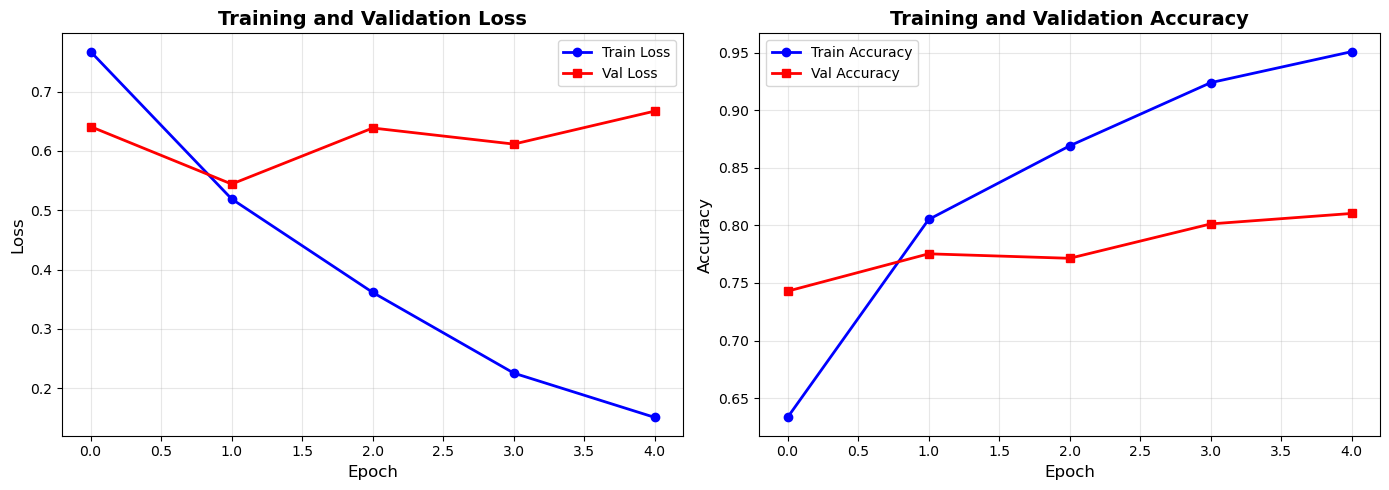

In [100]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Read metrics from CSV file
log_dir = Path(trainer.logger.log_dir)
metrics_file = log_dir / 'metrics.csv'

if metrics_file.exists():
    # Read CSV file
    df = pd.read_csv(metrics_file)
    
    # Extract specific columns and group by epoch
    metrics_df = df[['epoch', 'finetuning/train_acc', 'finetuning/train_loss', 
                     'finetuning/val_acc', 'finetuning/val_loss']].copy()
    
    # Drop rows where all metric values are NaN
    metrics_df = metrics_df.dropna(subset=['finetuning/train_acc', 'finetuning/train_loss',
                                            'finetuning/val_acc', 'finetuning/val_loss'], 
                                    how='all')
    
    # Group by epoch and take the first non-null value for each metric
    metrics_grouped = metrics_df.groupby('epoch').first()
    
    # Remove rows with NaN values in any column
    metrics_grouped = metrics_grouped.dropna()
    
    print("Metrics data:")
    print(metrics_grouped)
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs = metrics_grouped.index
    
    # Plot Loss
    ax1.plot(epochs, metrics_grouped['finetuning/train_loss'], 'b-', 
             label='Train Loss', marker='o', linewidth=2)
    ax1.plot(epochs, metrics_grouped['finetuning/val_loss'], 'r-', 
             label='Val Loss', marker='s', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Plot Accuracy
    ax2.plot(epochs, metrics_grouped['finetuning/train_acc'], 'b-', 
             label='Train Accuracy', marker='o', linewidth=2)
    ax2.plot(epochs, metrics_grouped['finetuning/val_acc'], 'r-', 
             label='Val Accuracy', marker='s', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Metrics file not found at {metrics_file}")
    print(f"Log directory: {log_dir}")
    print("Available files:")
    for f in log_dir.glob('*'):
        print(f"  - {f.name}")

#### 8.4.2 ROC Curves

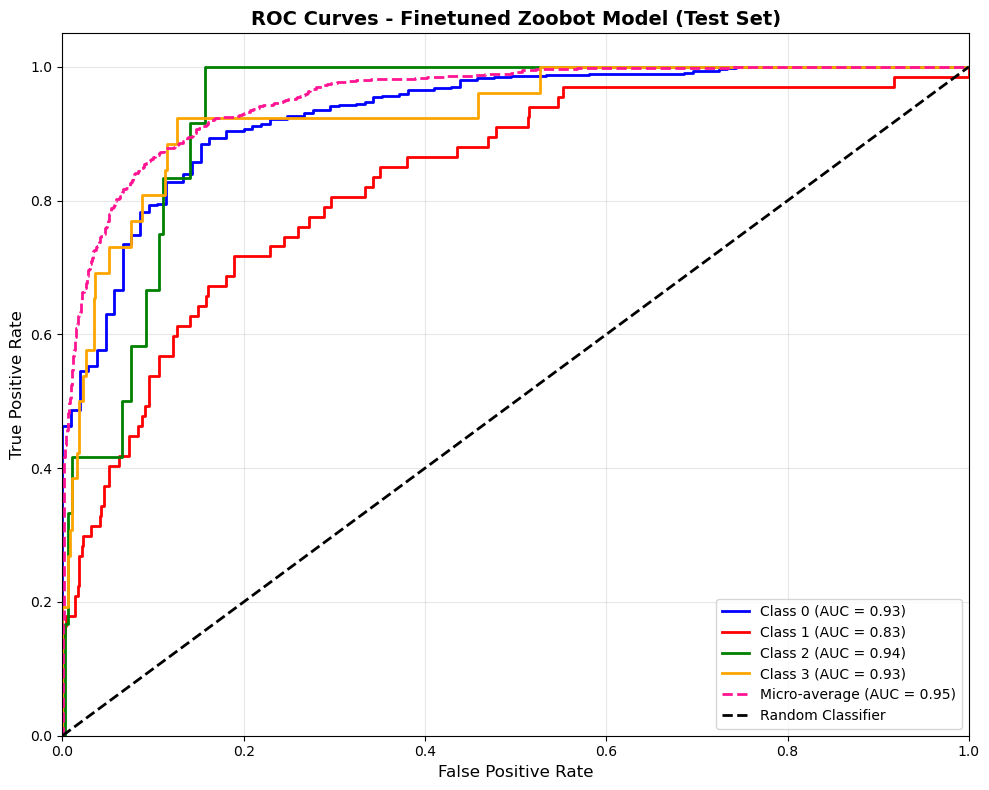

ROC AUC Scores:
  Class 0: 0.9316
  Class 1: 0.8299
  Class 2: 0.9351
  Class 3: 0.9306
  Micro-average: 0.9544


In [101]:
# Generate ROC curve for finetuned_model
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Get predictions on test set with probabilities
finetuned_model.eval()
all_probs = []
all_labels_roc = []

test_dataloader = datamodule.test_dataloader()
with torch.no_grad():
    for batch in test_dataloader:
        images = batch['image'].cpu()
        labels = batch['ring_class']
        
        # Get model outputs (logits)
        outputs = finetuned_model(images.cuda()).cpu()
        
        # Convert to probabilities
        probs = torch.softmax(outputs, dim=1)
        
        all_probs.append(probs.numpy())
        all_labels_roc.append(labels.numpy())

# Concatenate all batches
y_proba = np.vstack(all_probs)
y_true = np.hstack(all_labels_roc)

# Binarize labels for one-vs-rest ROC curves
n_classes = 4
y_bin = label_binarize(y_true, classes=list(range(n_classes)))

# Calculate ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), y_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# Plot ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(n_classes), colors):
    ax.plot(fpr[i], tpr[i], color=color, lw=2,
            label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

ax.plot(fpr_micro, tpr_micro, color='deeppink', linestyle='--', lw=2,
        label=f'Micro-average (AUC = {roc_auc_micro:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Finetuned Zoobot Model (Test Set)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("ROC AUC Scores:")
for i in range(n_classes):
    print(f"  Class {i}: {roc_auc[i]:.4f}")
print(f"  Micro-average: {roc_auc_micro:.4f}")

#### 8.4.3 Confusion Matrix

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

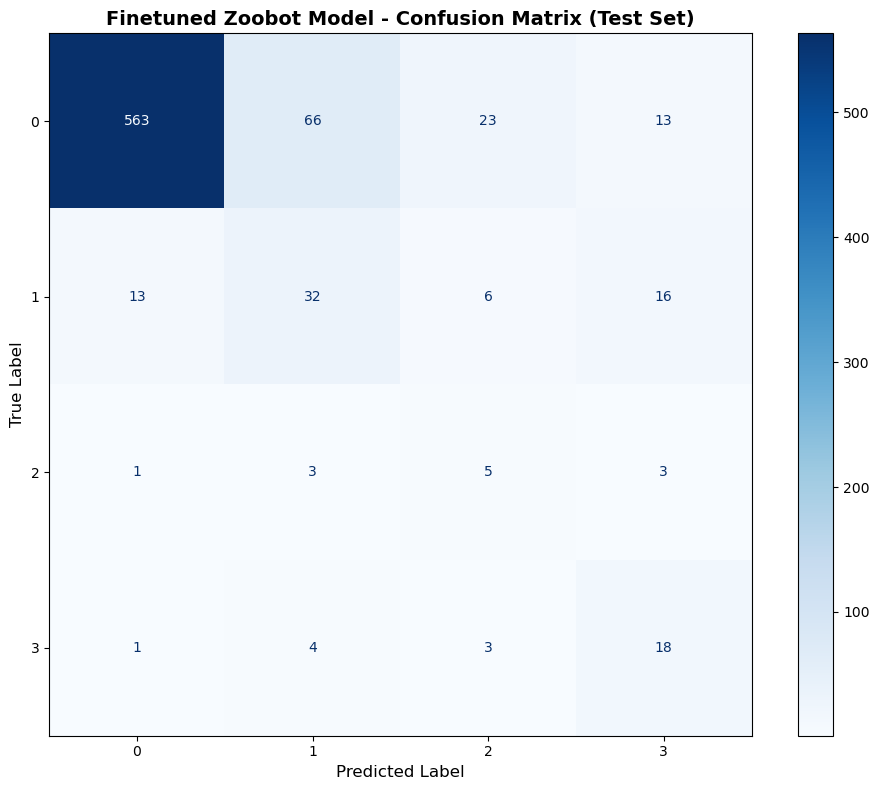

Confusion Matrix:
[[563  66  23  13]
 [ 13  32   6  16]
 [  1   3   5   3]
 [  1   4   3  18]]


In [102]:
# Generate confusion matrix for finetuned_model on test set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions on test set
predictions = trainer.predict(finetuned_model, datamodule=datamodule)

# Extract predictions and labels
all_preds = []
all_labels = []

for batch_predictions in predictions:
    # batch_predictions is a dictionary with 'ring_class' predictions
    preds = torch.argmax(torch.tensor(batch_predictions), dim=1) if isinstance(batch_predictions, dict) else torch.argmax(batch_predictions, dim=1)
    all_preds.extend(preds.cpu().numpy() if isinstance(preds, torch.Tensor) else preds)

# Get true labels from test dataset
test_dataloader = datamodule.test_dataloader()
for batch in test_dataloader:
    all_labels.extend(batch['ring_class'].numpy())

# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Get class labels
class_labels = list(range(4))  # 4 classes for ring_class

# Display confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Finetuned Zoobot Model - Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

## 9. Comparativa global + selección top-2 + ajuste fino


In [103]:
# =========================
# TABLA GLOBAL DE MODELOS
# =========================

tables = []

# 1 Modelos tabulares
if "combined" in globals():
    tab_table = combined.copy()
    tab_table["family"] = "tabular"
    tables.append(tab_table)

# 2️ Modelos CNN 
if "cnn_runs" in globals() and len(cnn_runs) > 0:
    cnn_table = pd.DataFrame(cnn_runs)
    cnn_table["family"] = "cnn"
    tables.append(cnn_table)

# 3️ Modelos CNN preentrenados
if "francisco_runs" in globals() and len(francisco_runs) > 0:
    fr_table = pd.DataFrame(francisco_runs)
    fr_table["family"] = "cnn_francisco"
    tables.append(fr_table)

if len(tables) == 0:
    raise ValueError("No hay tablas para concatenar.")

# Concatenar todo
global_table = pd.concat(tables, ignore_index=True, sort=False)

# Asegurar que exista f1_macro para ordenar
if "f1_macro" not in global_table.columns:
    raise ValueError("La tabla global no contiene la columna 'f1_macro'.")

global_table = global_table.sort_values(by="f1_macro", ascending=False).reset_index(drop=True)

# Guardar reporte final
global_table.to_csv(REPORTS_DIR / "global_model_comparison.csv", index=False)

global_table.sort_values(by="accuracy", ascending=False)

,model,f1_macro,accuracy,kappa,train_time_sec,fit_time_sec,predict_time_sec,params,stage,family,train_time_s,data_type,preprocess
2,zoobot_fits,0.515744,0.824675,0.433027,NaN,NaN,NaN,NaN,NaN,cnn_francisco,435.577897,NaN,NaN
0,efficientnet_b0__lupton_rgb,0.569441,0.717391,0.435139,NaN,NaN,NaN,NaN,NaN,cnn,72.804445,image,lupton_rgb
1,efficientnet_b0__unsharp_mask,0.531099,0.702899,0.401650,NaN,NaN,NaN,NaN,NaN,cnn,103.008548,image,unsharp_mask
4,resnet18__unsharp_mask,0.499720,0.644928,0.303891,NaN,NaN,NaN,NaN,NaN,cnn,82.373435,image,unsharp_mask
5,resnet18__lupton_rgb,0.476523,0.630435,0.263191,NaN,NaN,NaN,NaN,NaN,cnn,65.607462,image,lupton_rgb
3,resnet18__unsharp_lupton,0.509096,0.623188,0.263547,NaN,NaN,NaN,NaN,NaN,cnn,118.462194,image,unsharp_lupton
14,LinearSVC,0.279434,0.594203,0.003867,0.019411,0.014923,0.004486,"{""clf__C"": 1.0}",baseline,tabular,NaN,NaN,NaN
15,mobilenet_v3_small__lupton_rgb,0.248485,0.594203,-0.021412,NaN,NaN,NaN,NaN,NaN,cnn,41.531155,image,lupton_rgb
16,KNN,0.247706,0.586957,-0.029042,0.018347,0.013345,0.005001,"{""clf__n_neighbors"": 15}",baseline,tabular,NaN,NaN,NaN
12,mobilenet_v3_small__unsharp_mask,0.308480,0.579710,0.011119,NaN,NaN,NaN,NaN,NaN,cnn,72.489628,image,unsharp_mask


## 10. Conclusión y elección del modelo individual final


Conclusión comparativa final

La comparación global muestra que los modelos basados en imágenes superan consistentemente a los modelos tabulares. El mejor desempeño se obtuvo con ResNet18 utilizando preprocesamiento Lupton RGB, alcanzando un F1 macro de 0.402, superando al mejor modelo tabular ajustado (DecisionTree tuned, F1 = 0.385).

Esto confirma que las características tabulares (ra, dec, z y transformaciones derivadas) tienen una capacidad limitada para capturar la complejidad morfológica de los anillos galácticos, mientras que las CNN, al operar directamente sobre las imágenes FITS, logran extraer patrones espaciales relevantes.

En consecuencia, los modelos basados en imágenes se posicionan como la alternativa más adecuada para la siguiente etapa del proyecto.

## Referencias

- Géron, A. (2022). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (3rd ed.). O’Reilly Media.
